In [3]:
from google.colab import files
uploaded = files.upload()

Saving clean_dataset.csv to clean_dataset.csv


In [4]:
import numpy as np
import pandas as pd

df = pd.read_csv('clean_dataset.csv')

In [5]:
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [6]:
df.columns

Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'Industry',
       'Ethnicity', 'YearsEmployed', 'PriorDefault', 'Employed', 'CreditScore',
       'DriversLicense', 'Citizen', 'ZipCode', 'Income', 'Approved'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Gender,0
Age,0
Debt,0
Married,0
BankCustomer,0
Industry,0
Ethnicity,0
YearsEmployed,0
PriorDefault,0
Employed,0


In [8]:
df.shape

(690, 16)

In [9]:
df.size

11040

In [10]:
df.describe()

,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


In [11]:
df.dtypes

,0
Gender,int64
Age,float64
Debt,float64
Married,int64
BankCustomer,int64
Industry,object
Ethnicity,object
YearsEmployed,float64
PriorDefault,int64
Employed,int64


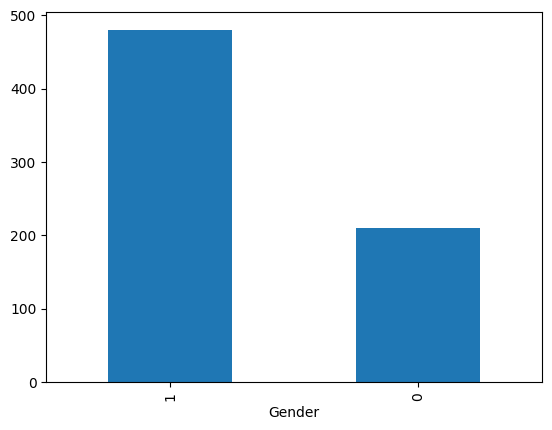

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
df['Gender'].value_counts().plot(kind = 'bar')
plt.show()

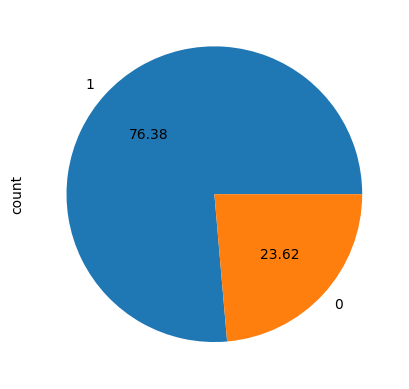

In [15]:
df['BankCustomer'].value_counts().plot(kind = 'pie', autopct='%.2f')
plt.show()

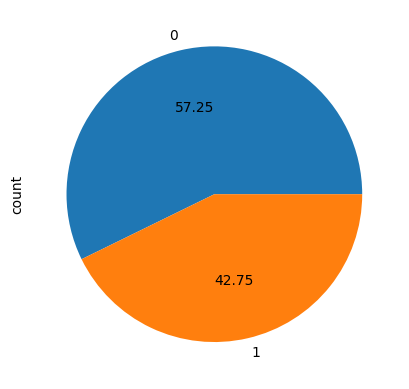

In [17]:
df['Employed'].value_counts().plot(kind = 'pie', autopct='%.2f')
plt.show()

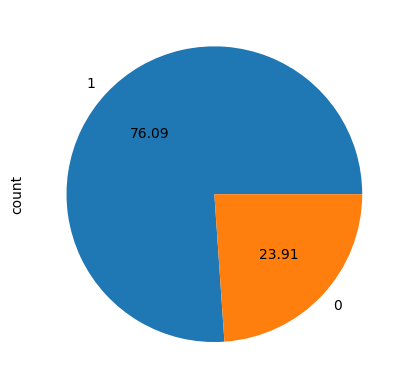

In [26]:
df['Married'].value_counts().plot(kind = 'pie', autopct='%.2f')
plt.show()

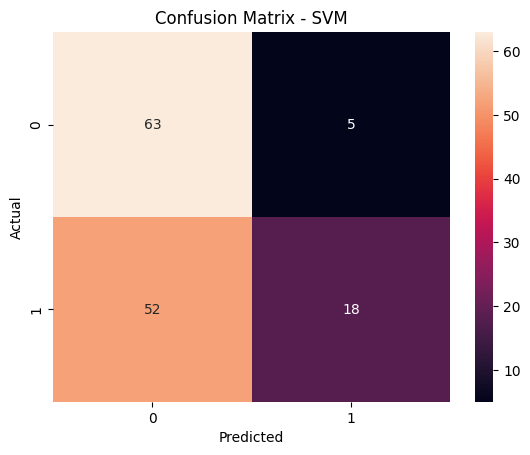

Accuracy: 0.5869565217391305

Confusion Matrix:
 [[63  5]
 [52 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.93      0.69        68
           1       0.78      0.26      0.39        70

    accuracy                           0.59       138
   macro avg       0.67      0.59      0.54       138
weighted avg       0.67      0.59      0.54       138



In [32]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'Approved' is the target variable (as typically done in credit approval tasks)
X = df.drop('Approved', axis=1)
y = df['Approved']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train SVM model
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Confusion Matrix (SVM)
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

In [34]:
# accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy)

Accuracy: 0.5869565217391305


In [40]:
# implementing another model
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [42]:
#accuracy
# Generate predictions for the Decision Tree model
y_train_pred_dt = model.predict(X_train)
y_test_pred_dt = model.predict(X_test)

print('training accuracy', accuracy_score(y_train, y_train_pred_dt))
print('testing accuracy', accuracy_score(y_test, y_test_pred_dt))

training accuracy 1.0
testing accuracy 0.7391304347826086


In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [46]:
#implementig model
#logistic regration
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [49]:
#prediction
y_pred_train=model.predict(X_train)
y_pred_test=model.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score
print('training accuracy:',accuracy_score(y_train,y_pred_train))
print('testing accuracy:',accuracy_score(y_test,y_pred_test))


training accuracy: 0.8713768115942029
testing accuracy: 0.855072463768116
